## Data Wrangling with Python 

### Overview

WeRateDogs is a Twitter account that rates people's dogs with a humorous comment about the dog. These ratings almost always have a denominator of 10. The numerators, though? Almost always greater than 10. 11/10, 12/10, 13/10, etc. Why? Because "they're good dogs Brent." WeRateDogs has over 4 million followers and has received international media coverage. WeRateDogs data have been collected for analysis through:
- Twitter archived data
- Image prediction from a modelling
- Scrapped data from Twitter API

The varying sources of the data has made it necessary for the data to be examined and cleaned where necessary for data integrity. The documented processes below details the steps taken to clean the files.

### Required Libraries 

In [33]:

import pandas as pd
import matplotlib.pyplot as plt
import tweepy
import requests
import json
import re
import datetime as dt


### Data Gathering

#### Define

Twitter archive is downloaded using requests

### Code

In [164]:
url = 'https://d17h27t6h515a5.cloudfront.net/topher/2017/August/59a4e958_twitter-archive-enhanced/twitter-archive-enhanced.csv'
r = requests.get(url)

with open ('twitter_archive_files.csv', 'wb') as file:
    file.write(r.content)
twitter_archive = pd.read_csv('twitter_archive_files.csv')

#### Test

In [160]:
twitter_archive.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None


In [8]:
twitter_archive.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2356 non-null   object 
 4   source                      2356 non-null   object 
 5   text                        2356 non-null   object 
 6   retweeted_status_id         181 non-null    float64
 7   retweeted_status_user_id    181 non-null    float64
 8   retweeted_status_timestamp  181 non-null    object 
 9   expanded_urls               2297 non-null   object 
 10  rating_numerator            2356 non-null   int64  
 11  rating_denominator          2356 non-null   int64  
 12  name                        2356 non-null   object 
 13  doggo                       2356 

In [12]:
len(twitter_archive)

2356

#### Define

Image prediction is called from a tsv linked url

#### Code

In [159]:


url = 'https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv'
r = requests.get(url)

with open ('images.tsv', 'wb') as file:
    file.write(r.content)

image_predictions = pd.read_csv('images.tsv', sep='\t' )

#### Test

In [10]:
image_predictions

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True
...,...,...,...,...,...,...,...,...,...,...,...,...
2070,891327558926688256,https://pbs.twimg.com/media/DF6hr6BUMAAzZgT.jpg,2,basset,0.555712,True,English_springer,0.225770,True,German_short-haired_pointer,0.175219,True
2071,891689557279858688,https://pbs.twimg.com/media/DF_q7IAWsAEuuN8.jpg,1,paper_towel,0.170278,False,Labrador_retriever,0.168086,True,spatula,0.040836,False
2072,891815181378084864,https://pbs.twimg.com/media/DGBdLU1WsAANxJ9.jpg,1,Chihuahua,0.716012,True,malamute,0.078253,True,kelpie,0.031379,True
2073,892177421306343426,https://pbs.twimg.com/media/DGGmoV4XsAAUL6n.jpg,1,Chihuahua,0.323581,True,Pekinese,0.090647,True,papillon,0.068957,True


In [20]:
list(image_predictions)

['tweet_id',
 'jpg_url',
 'img_num',
 'p1',
 'p1_conf',
 'p1_dog',
 'p2',
 'p2_conf',
 'p2_dog',
 'p3',
 'p3_conf',
 'p3_dog']

In [23]:
image_predictions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  2075 non-null   int64  
 1   jpg_url   2075 non-null   object 
 2   img_num   2075 non-null   int64  
 3   p1        2075 non-null   object 
 4   p1_conf   2075 non-null   float64
 5   p1_dog    2075 non-null   bool   
 6   p2        2075 non-null   object 
 7   p2_conf   2075 non-null   float64
 8   p2_dog    2075 non-null   bool   
 9   p3        2075 non-null   object 
 10  p3_conf   2075 non-null   float64
 11  p3_dog    2075 non-null   bool   
dtypes: bool(3), float64(3), int64(2), object(4)
memory usage: 152.1+ KB


#### Define

Data scrapping with Twitter APi

#### Code

In [211]:
consumer_key = ''
consumer_secret = ''
access_token = ''
access_token_secret = ''

In [ ]:
auth = tweepy.AppAuthHandler(consumer_key, consumer_secret)
auth.set_access_token(access_token, access_token_secret)
api = tweepy.API(auth, wait_on_rate_limit=True)

In [213]:
tweet_ids = twitter_archive['tweet_id'].values
len(tweet_ids)

2356

In [ ]:
count = 0
fails_dict = {}

with open('tweet_json.txt', 'w') as outfile:
    for tweet_id in tweet_ids:
        count+= 1
        print(str(count) + ": " + str(tweet_id))
        try:
            tweet = api.get_status(tweet_id, tweet_mode='extended')
            json.dump(tweet._json, outfile)
            print('Success')
            outfile.write('\n')
        except Exception as e:
            print('Fail')
            fails_dict[tweet_id] = e
        print(fails_dict)

In [214]:
twitter_data = pd.read_json('tweet_json.txt', lines=True)

#### Test

In [218]:
twitter_data.columns

Index(['created_at', 'id', 'id_str', 'full_text', 'truncated',
       'display_text_range', 'entities', 'extended_entities', 'source',
       'in_reply_to_status_id', 'in_reply_to_status_id_str',
       'in_reply_to_user_id', 'in_reply_to_user_id_str',
       'in_reply_to_screen_name', 'user', 'geo', 'coordinates', 'place',
       'contributors', 'is_quote_status', 'retweet_count', 'favorite_count',
       'favorited', 'retweeted', 'possibly_sensitive',
       'possibly_sensitive_appealable', 'lang', 'retweeted_status',
       'quoted_status_id', 'quoted_status_id_str', 'quoted_status_permalink',
       'quoted_status'],
      dtype='object')

### Data Issues

#### Quality issues

`twitter_archive` table
- The 'tweet_id' column should be of string datatype
- There are some missing values and irrelevant fields (in_reply_to_status_id, in_reply_to_user_id)
- The 'timestamp' column should be of datetime datatype
- The 'retweeted_status_timestamp' should be of datetime datatype 
- There are 745 dogs with name 'None'
- Rename columns for easy identification
- The orientation of the table with the dog stages (doggo, floofer, pupper, puppo) is not convenient for analysis

`twitter_clean` table
- The 'id' column should be of string datatype


`image_predictions` table
- The 'tweet_id' column should be of string datatype
- The prediction of the model to be dog isnot consistent in the p1_dog
- The description of the columns are unclear


#### Tidiness issues

`twitter_archive` table
- 'doggo', 'floofer', 'pupper' and 'poppo'...each of these variables does not form a column
- 'tweet_id' is duplicated in all 3 tables 
- `twitter_clean` table should be part of the `twitter_archive_enhanced` table
- There are contents to be extracted from the 'source' column


### Accessing and Cleaning the Data

#### Define

Copies of each dataframe are created for version control and the relevant fields of the twitter scrapped data extracted i.e  id, retweet_count and favorite_count

#### Code

In [233]:

archive_clean = twitter_archive.copy()
image_clean = image_predictions.copy()
twitter_clean = twitter_data[['id','retweet_count','favorite_count']]


### Test

In [186]:
image_clean.head()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


In [188]:
archive_clean.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None


In [220]:
twitter_clean.head()

,id,retweet_count,favorite_count
0,892420643555336193,6902,32992
1,892177421306343426,5202,28535
2,891815181378084864,3433,21447
3,891689557279858688,7117,35992
4,891327558926688256,7637,34415


#### Define
Convert 'tweet_id' in all tables to string datatype

#### Code

In [234]:
archive_clean['tweet_id'] = archive_clean.tweet_id.astype(str)
image_clean['tweet_id'] = image_clean.tweet_id.astype(str)
twitter_clean['id'] = twitter_clean.id.astype(str)

/var/folders/s5/dkqsyftn5mb3f9fbxn0wckwh0000gn/T/ipykernel_1721/2545868598.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  twitter_clean['id'] = twitter_clean.id.astype(str)


#### Test

In [190]:
archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   object 
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2356 non-null   object 
 4   source                      2356 non-null   object 
 5   text                        2356 non-null   object 
 6   retweeted_status_id         181 non-null    float64
 7   retweeted_status_user_id    181 non-null    float64
 8   retweeted_status_timestamp  181 non-null    object 
 9   expanded_urls               2297 non-null   object 
 10  rating_numerator            2356 non-null   int64  
 11  rating_denominator          2356 non-null   int64  
 12  name                        2356 non-null   object 
 13  doggo                       2356 

In [225]:
twitter_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2326 entries, 0 to 2325
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              2326 non-null   object
 1   retweet_count   2326 non-null   int64 
 2   favorite_count  2326 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 54.6+ KB


#### Define

Convert 'timestamp' on archive_clean to datetime, extracting the year and month into seperate fields

#### Code

In [235]:
archive_clean.timestamp = pd.to_datetime(archive_clean.timestamp)

archive_clean['year'] = archive_clean.timestamp.dt.year
archive_clean['month'] = archive_clean.timestamp.dt.month_name()

#### Test



In [192]:
archive_clean.columns

Index(['tweet_id', 'in_reply_to_status_id', 'in_reply_to_user_id', 'timestamp',
       'source', 'text', 'retweeted_status_id', 'retweeted_status_user_id',
       'retweeted_status_timestamp', 'expanded_urls', 'rating_numerator',
       'rating_denominator', 'name', 'doggo', 'floofer', 'pupper', 'puppo',
       'year', 'month'],
      dtype='object')

#### Define

Create a new column "dog_stage" to hold the value of dog stage from column values ['doggo', 'floofer', 'pupper', 'puppo']

#### Code

In [236]:


def dogtionary(x):
    stages = ['doggo', 'floofer', 'pupper', 'puppo']
    for _ in stages:
        if x[_] != "None":
            return x[_]
    return 'None'
archive_clean['dog_stage'] = archive_clean.apply(dogtionary, axis =1)

#### Test

In [194]:
archive_clean.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo,year,month,dog_stage
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None,2017,August,None
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None,2017,August,None
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None,2017,July,None
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None,2017,July,None
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None,2017,July,None


#### Define

Drop columns that are not relevant to our analysis and rename the necessary columns appropriately for easy identification

#### Code

In [237]:

archive_clean.drop(columns = ['in_reply_to_status_id','in_reply_to_user_id','retweeted_status_id', 'retweeted_status_user_id', 'retweeted_status_timestamp', 'expanded_urls','doggo', 'floofer', 'pupper', 'puppo' ], axis =1, inplace = True)
archive_clean.rename(columns = {'text':' dog_profile', 'name': 'dog_name'}, inplace =True)
twitter_clean.rename(columns = {'id':'tweet_id'}, inplace = True)

/var/folders/s5/dkqsyftn5mb3f9fbxn0wckwh0000gn/T/ipykernel_1721/2578995360.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  twitter_clean.rename(columns = {'id':'tweet_id'}, inplace = True)


#### Test

In [202]:
archive_clean.head()

,tweet_id,timestamp,source,dog_profile,rating_numerator,rating_denominator,dog_name,year,month,dog_stage
0,892420643555336193,2017-08-01 16:23:56+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,13,10,Phineas,2017,August,None
1,892177421306343426,2017-08-01 00:17:27+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,13,10,Tilly,2017,August,None
2,891815181378084864,2017-07-31 00:18:03+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,12,10,Archie,2017,July,None
3,891689557279858688,2017-07-30 15:58:51+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,13,10,Darla,2017,July,None
4,891327558926688256,2017-07-29 16:00:24+00:00,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,12,10,Franklin,2017,July,None


#### Define

Regex funciton tp extract content from 'source' HTML tag

#### Code

In [204]:
#regex function to extract content from HTML tag
def text(x):
    result = re.search('>([^<]*)<', x).group(1)
    return result
archive_clean['source'] = archive_clean['source'].map(lambda x: text(x))

#### Test

In [205]:
archive_clean

,tweet_id,timestamp,source,dog_profile,rating_numerator,rating_denominator,dog_name,year,month,dog_stage
0,892420643555336193,2017-08-01 16:23:56+00:00,Twitter for iPhone,This is Phineas. He's a mystical boy. Only eve...,13,10,Phineas,2017,August,None
1,892177421306343426,2017-08-01 00:17:27+00:00,Twitter for iPhone,This is Tilly. She's just checking pup on you....,13,10,Tilly,2017,August,None
2,891815181378084864,2017-07-31 00:18:03+00:00,Twitter for iPhone,This is Archie. He is a rare Norwegian Pouncin...,12,10,Archie,2017,July,None
3,891689557279858688,2017-07-30 15:58:51+00:00,Twitter for iPhone,This is Darla. She commenced a snooze mid meal...,13,10,Darla,2017,July,None
4,891327558926688256,2017-07-29 16:00:24+00:00,Twitter for iPhone,This is Franklin. He would like you to stop ca...,12,10,Franklin,2017,July,None
...,...,...,...,...,...,...,...,...,...,...
2351,666049248165822465,2015-11-16 00:24:50+00:00,Twitter for iPhone,Here we have a 1949 1st generation vulpix. Enj...,5,10,None,2015,November,None
2352,666044226329800704,2015-11-16 00:04:52+00:00,Twitter for iPhone,This is a purebred Piers Morgan. Loves to Netf...,6,10,a,2015,November,None
2353,666033412701032449,2015-11-15 23:21:54+00:00,Twitter for iPhone,Here is a very happy pup. Big fan of well-main...,9,10,a,2015,November,None
2354,666029285002620928,2015-11-15 23:05:30+00:00,Twitter for iPhone,This is a western brown Mitsubishi terrier. Up...,7,10,a,2015,November,None


In [206]:
archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   tweet_id            2356 non-null   object             
 1   timestamp           2356 non-null   datetime64[ns, UTC]
 2   source              2356 non-null   object             
 3    dog_profile        2356 non-null   object             
 4   rating_numerator    2356 non-null   int64              
 5   rating_denominator  2356 non-null   int64              
 6   dog_name            2356 non-null   object             
 7   year                2356 non-null   int64              
 8   month               2356 non-null   object             
 9   dog_stage           2356 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(3), object(6)
memory usage: 184.2+ KB


In [96]:
image_clean.head(3)

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True


#### Define

The function below evaluates the 3 predictions from the machine learning models and selects the breed name for where the model predicts that the image contains a dog.

#### Code

In [207]:
def breed(x):
    if x['p1_dog']:
        return x['p1']
    elif x['p2_dog']:
        return x['p2']
    elif x['p3_dog']:
        return x['p3']
    else:
        return "None"
    
image_clean['breed'] = image_clean.apply(breed, axis =1)
    

#### Test

In [119]:
image_clean.breed.value_counts()

golden_retriever        173
Labrador_retriever      113
Pembroke                 96
Chihuahua                95
pug                      65
                       ... 
Scotch_terrier            1
EntleBucher               1
Japanese_spaniel          1
standard_schnauzer        1
Bouvier_des_Flandres      1
Name: breed, Length: 113, dtype: int64

#### Define

Rows where the image prediction isnt evaluated as dogs are removed and irrelevant columns are dropped from the image_clean table

#### Code

In [208]:

wrong_images = image_clean[image_clean['breed']=="None"]
image_clean.drop(wrong_images.index, inplace = True)

In [209]:
image_clean.drop(columns = ['img_num','p1','p1_conf','p1_dog','p2','p2_conf','p2_dog','p3','p3_conf','p3_dog'], axis=1, inplace=True)

#### Test

In [210]:
image_clean.head()

,tweet_id,jpg_url,breed
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,Welsh_springer_spaniel
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,redbone
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,German_shepherd
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,Rhodesian_ridgeback
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,miniature_pinscher


#### Define

The three data frames created i.e twitter_clean, archive_clean, images_clean are to be merged to create a masterfile

#### Code

In [150]:
master = archive_clean.merge(image_clean, on = "tweet_id", how='left')

In [228]:
master.head()

,tweet_id,timestamp,source,dog_profile,rating_numerator,rating_denominator,dog_name,year,month,dog_stage,jpg_url,breed
0,892420643555336193,2017-08-01 16:23:56+00:00,Twitter for iPhone,This is Phineas. He's a mystical boy. Only eve...,13,10,Phineas,2017,August,None,NaN,NaN
1,892177421306343426,2017-08-01 00:17:27+00:00,Twitter for iPhone,This is Tilly. She's just checking pup on you....,13,10,Tilly,2017,August,None,https://pbs.twimg.com/media/DGGmoV4XsAAUL6n.jpg,Chihuahua
2,891815181378084864,2017-07-31 00:18:03+00:00,Twitter for iPhone,This is Archie. He is a rare Norwegian Pouncin...,12,10,Archie,2017,July,None,https://pbs.twimg.com/media/DGBdLU1WsAANxJ9.jpg,Chihuahua
3,891689557279858688,2017-07-30 15:58:51+00:00,Twitter for iPhone,This is Darla. She commenced a snooze mid meal...,13,10,Darla,2017,July,None,https://pbs.twimg.com/media/DF_q7IAWsAEuuN8.jpg,Labrador_retriever
4,891327558926688256,2017-07-29 16:00:24+00:00,Twitter for iPhone,This is Franklin. He would like you to stop ca...,12,10,Franklin,2017,July,None,https://pbs.twimg.com/media/DF6hr6BUMAAzZgT.jpg,basset


In [241]:
twitter_archive_master = master.merge(twitter_clean, on = "tweet_id", how = 'left')

#### Test

In [242]:
twitter_archive_master.head(4)

,tweet_id,timestamp,source,dog_profile,rating_numerator,rating_denominator,dog_name,year,month,dog_stage,jpg_url,breed,retweet_count,favorite_count
0,892420643555336193,2017-08-01 16:23:56+00:00,Twitter for iPhone,This is Phineas. He's a mystical boy. Only eve...,13,10,Phineas,2017,August,None,NaN,NaN,6902.0,32992.0
1,892177421306343426,2017-08-01 00:17:27+00:00,Twitter for iPhone,This is Tilly. She's just checking pup on you....,13,10,Tilly,2017,August,None,https://pbs.twimg.com/media/DGGmoV4XsAAUL6n.jpg,Chihuahua,5202.0,28535.0
2,891815181378084864,2017-07-31 00:18:03+00:00,Twitter for iPhone,This is Archie. He is a rare Norwegian Pouncin...,12,10,Archie,2017,July,None,https://pbs.twimg.com/media/DGBdLU1WsAANxJ9.jpg,Chihuahua,3433.0,21447.0
3,891689557279858688,2017-07-30 15:58:51+00:00,Twitter for iPhone,This is Darla. She commenced a snooze mid meal...,13,10,Darla,2017,July,None,https://pbs.twimg.com/media/DF_q7IAWsAEuuN8.jpg,Labrador_retriever,7117.0,35992.0


In [244]:
twitter_archive_master.describe()

,rating_numerator,rating_denominator,year,retweet_count,favorite_count
count,2356.000000,2356.000000,2356.000000,2326.000000,2326.000000
mean,13.126486,10.455433,2015.912139,2432.910146,6890.437231
std,45.876648,6.745237,0.700262,4118.028846,10705.986568
min,0.000000,0.000000,2015.000000,0.000000,0.000000
25%,10.000000,10.000000,2015.000000,489.000000,1196.000000
50%,11.000000,10.000000,2016.000000,1130.500000,2985.000000
75%,12.000000,10.000000,2016.000000,2816.750000,8416.500000
max,1776.000000,170.000000,2017.000000,69585.000000,142117.000000


### Storing the master dataframe to system

From the wrangled dataset, we aim to investigate the cleaned master file to gain some insights from @WeRateDogs data

In [245]:
twitter_archive_master.to_csv('twitter_archive_master', index=False)

## Data Visualization and Insights

In [247]:
twitter_archive_master.head(3)

,tweet_id,timestamp,source,dog_profile,rating_numerator,rating_denominator,dog_name,year,month,dog_stage,jpg_url,breed,retweet_count,favorite_count
0,892420643555336193,2017-08-01 16:23:56+00:00,Twitter for iPhone,This is Phineas. He's a mystical boy. Only eve...,13,10,Phineas,2017,August,None,NaN,NaN,6902.0,32992.0
1,892177421306343426,2017-08-01 00:17:27+00:00,Twitter for iPhone,This is Tilly. She's just checking pup on you....,13,10,Tilly,2017,August,None,https://pbs.twimg.com/media/DGGmoV4XsAAUL6n.jpg,Chihuahua,5202.0,28535.0
2,891815181378084864,2017-07-31 00:18:03+00:00,Twitter for iPhone,This is Archie. He is a rare Norwegian Pouncin...,12,10,Archie,2017,July,None,https://pbs.twimg.com/media/DGBdLU1WsAANxJ9.jpg,Chihuahua,3433.0,21447.0


### Insight I - What is the most popular dog breed?

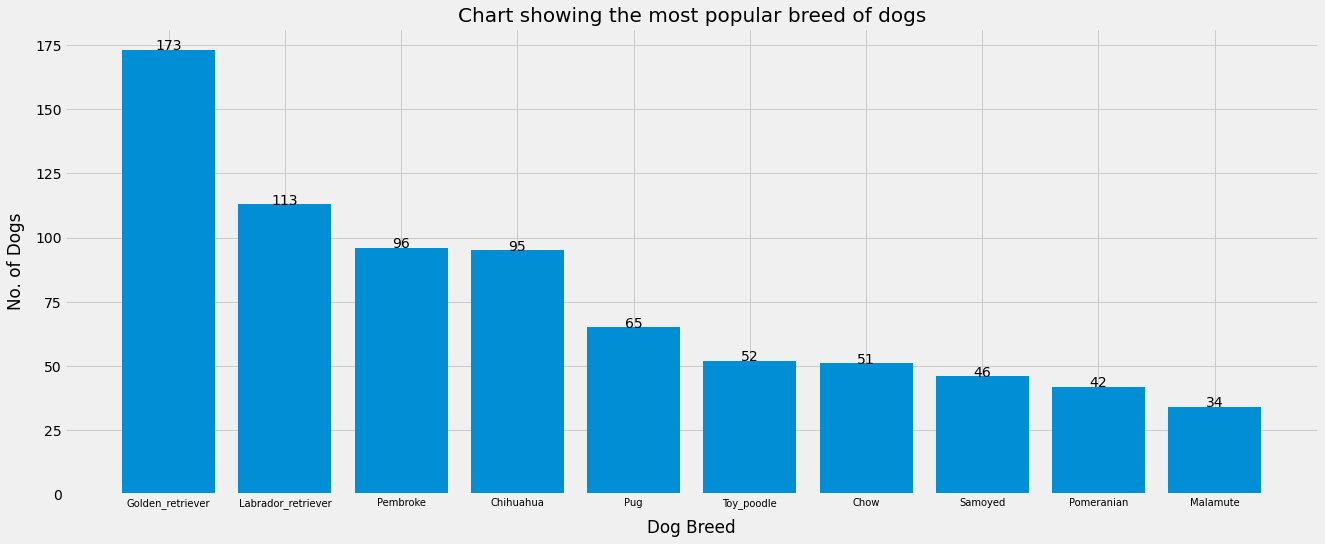

In [278]:
breeds = twitter_archive_master.breed.value_counts().sort_values(ascending=False).reset_index().head(10)
breeds['index'] = breeds['index'].str.capitalize()
x = breeds['index']
y = breeds.breed
def addlabels(x,y):      #function  to add label to chart
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha = 'center')
plt.style.use('fivethirtyeight')
plt.figure(figsize=(20,8))
plt.bar(x,y)
addlabels(x,y)
plt.title('Chart showing the most popular breed of dogs', fontsize=20)
plt.xlabel('Dog Breed', labelpad=10)
plt.ylabel('No. of Dogs', labelpad=10)
plt.xticks(fontsize=10)
plt.show()

The above chart shows the top 10 most popular breed of dogs posted on the @WeRateDogs twitter page with Golden retriever, Labrador retriever and Pembroke leading the chart with 173, 113 and 96 respectively.

### Insight II - What is the most common tweet source?

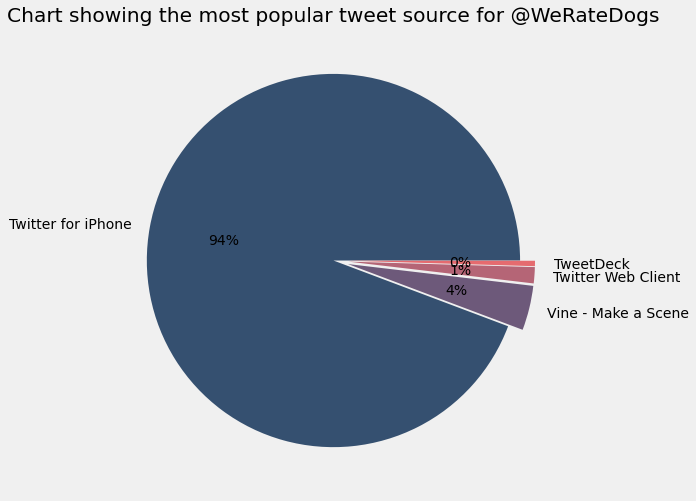

In [291]:
tweet_source = twitter_archive_master.source.value_counts().sort_values(ascending=False).reset_index()
label = tweet_source['index']
value = tweet_source['source']
colors = ["#355070", "#6d597a", "#b56576", "#e56b6f"]
plt.style.use('fivethirtyeight')
plt.figure(figsize=(8,8))
plt.pie(
    value, 
    colors=colors, 
    labels=label, 
    autopct='%1.0f%%', 
    explode=(0,0.08,0.08,0.08)
)
plt.title('Chart showing the most popular tweet source for @WeRateDogs')
plt.show()

The chart above shows there are 4 sources of tweets for @WeRateDogs, they are:
- Twitter for iPhone
- Vine - Make a Scene
- Twitter Web Client 
- TweetDeck. 

From the chart it can be seen that Twitter for iPhone is the most popular source/platform in which tweet for dog rating is sourced with a total of 2221(94%) tweets and in second place is Vine - Make a Scene with 91 (4%) tweets..This informs us that the mobile platform (specifically, iPhone) is the most popular source of tweets.

### Insight III - @WeRateDogs Tweets Performance Over Time

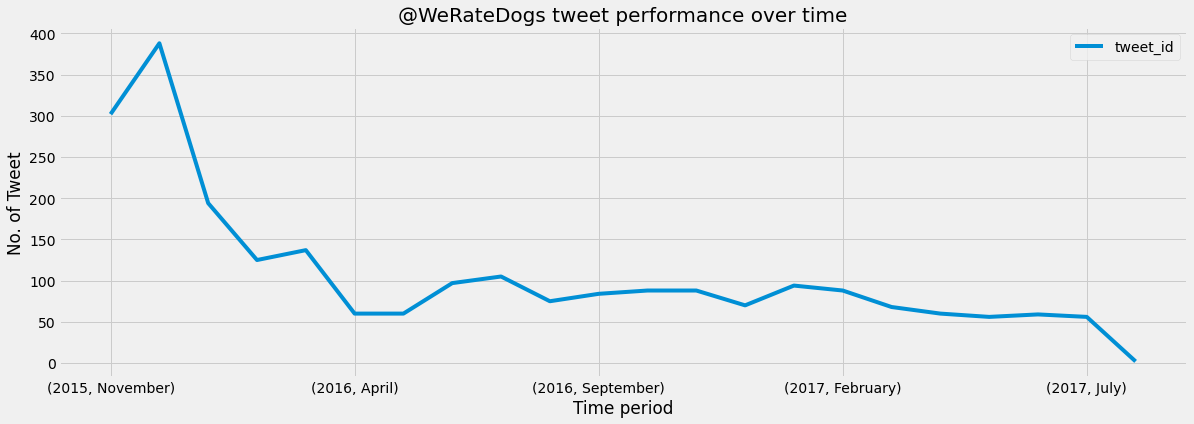

In [304]:
ordered_months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
twitter_archive_master['month'] = pd.Categorical(twitter_archive_master['month'], categories=ordered_months, ordered=True)
performance = twitter_archive_master.groupby(['year', 'month'])['tweet_id'].count().reset_index()
performance = performance[performance['tweet_id']!=0]
performance.set_index(['year', 'month'], inplace=True)
performance.plot(kind='line',
            figsize=(18,6), 
            xlabel='Time period',
            ylabel='No. of Tweet'

)
plt.title('@WeRateDogs tweet performance over time', fontsize=20)
plt.show()

From the chart above, @WeRateDogs peak tweets was in December 2015 with 388 tweets. The number of tweets saw subsequent highs and lows after this period.

### Insight IV - Tweet with the most engagement (retweet and favorites count)

/var/folders/s5/dkqsyftn5mb3f9fbxn0wckwh0000gn/T/ipykernel_1721/1665810319.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tweet_engagement['total_engagement'] = tweet_engagement['retweet_count'] + tweet_engagement['favorite_count']


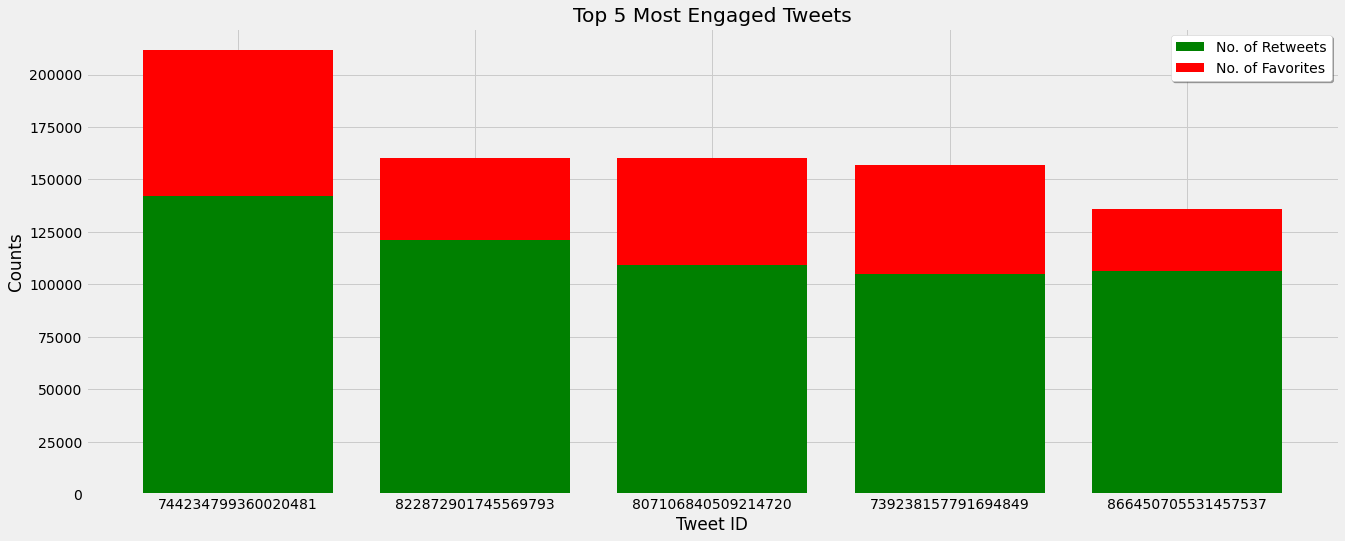

In [324]:
tweet_engagement = twitter_archive_master[['tweet_id','retweet_count','favorite_count']]
tweet_engagement['total_engagement'] = tweet_engagement['retweet_count'] + tweet_engagement['favorite_count']
tweet_engagement = tweet_engagement.sort_values('total_engagement', ascending=False).head(5)
x = tweet_engagement['tweet_id']
y = tweet_engagement['retweet_count']
z = tweet_engagement['favorite_count']
a = tweet_engagement['total_engagement']
plt.figure(figsize=(20,8))
plt.bar(x, z, color='green', label = 'No. of Retweets')
plt.bar(x, y, color='red', bottom = z ,label='No. of Favorites')
plt.title('Top 5 Most Engaged Tweets')
plt.ylabel('Counts')
plt.xlabel('Tweet ID')
plt.legend(frameon=True, shadow=True, facecolor='white')

In [355]:

twitter_archive_master[twitter_archive_master['tweet_id']== '744234799360020481']


,tweet_id,timestamp,source,dog_profile,rating_numerator,rating_denominator,dog_name,year,month,dog_stage,jpg_url,breed,retweet_count,favorite_count
1039,744234799360020481,2016-06-18 18:26:18+00:00,Twitter for iPhone,Here's a doggo realizing you can stand in a po...,13,10,None,2016,June,doggo,https://pbs.twimg.com/ext_tw_video_thumb/74423...,Labrador_retriever,69585.0,142117.0


The chart above shows the cummulative engagement of the tweets (No. of retweets and engagements). Tweet ID 744234799360020481 which is a Labrador_retriever tops the chart 69585 and 142117 retweets and favorites respectively. The tweet was posted 18th June 2016.

### Insight V - @WeRateDogs chart by dog stages

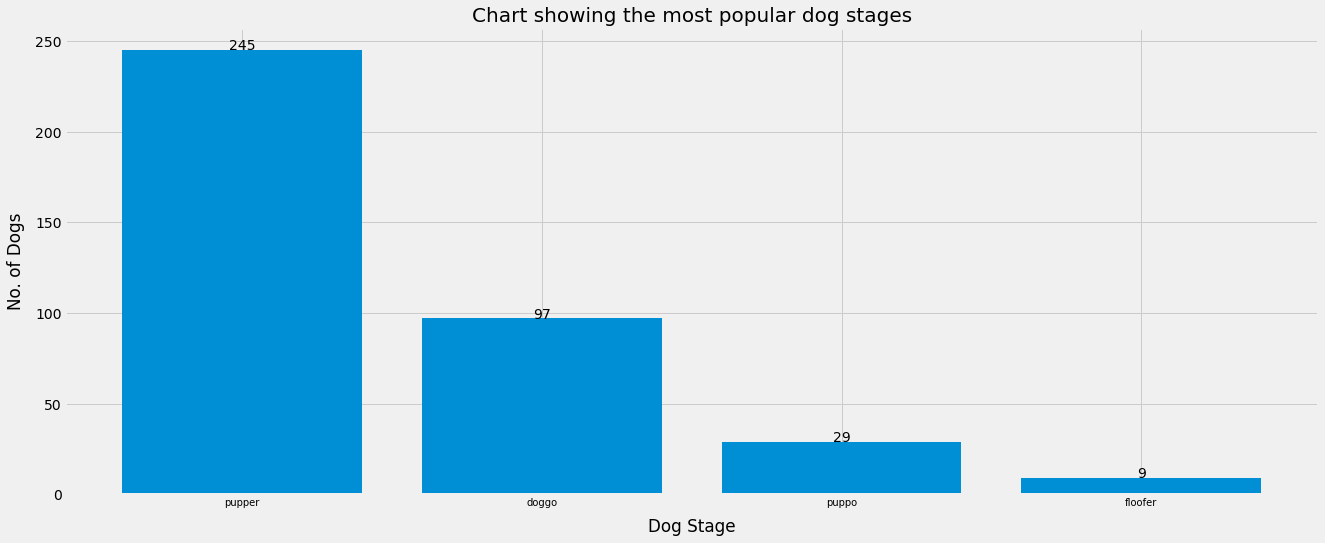

In [366]:
stage = twitter_archive_master[twitter_archive_master.dog_stage != "None"]
stage = stage.dog_stage.value_counts().reset_index()
stage
x = stage['index']
y = stage['dog_stage']
def addlabels(x,y):      #function  to add label to chart
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha = 'center')
plt.style.use('fivethirtyeight')
plt.figure(figsize=(20,8))
plt.bar(x,y)
addlabels(x,y)
plt.title('Chart showing the most popular dog stages', fontsize=20)
plt.xlabel('Dog Stage', labelpad=10)
plt.ylabel('No. of Dogs', labelpad=10)
plt.xticks(fontsize=10)
plt.show()


Analysis shows that the most popular dog stage in the available data is the Pupper. However the dataset contains 1976 records without the stages identified and this may affect the result if collated.